# Vergleich der 3 Prompting-Ansätze (Allgemeine Verbandsklassen)

Dieses Notebook vergleicht die Evaluierungsergebnisse aller 3 Prompt-Ansätze für den generischen Produktkatalog:
1. **Zero-Shot**
2. **Few-Shot** (2 Beispielwunden: `wunde_18` & `wunde_28`)
3. **2-Stage Chain-of-Thought (CoT)**

Für jeden Ansatz wird die Haupt-Metrik (Score / F1-Score (Mean)) und die Genauigkeit (Exact-Match-Rate) einmal **roh (Phase 0)** und einmal **normalisiert (Phase 1)** verglichen sowie der Direktvergleich aller 3 Ansätze, eine Gesamt-Set-Analyse, eine Wortanzahl-Effizienzanalyse, der Baseline-Vergleich und die wissenschaftliche Kategorie-Heatmap dargestellt.

In [1]:
import sys
import os
import pandas as pd

# Pfad anpassen, um utils_notebook und das eval-Modul zu importieren
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from utils_notebook.metrics_explorer import calculate_scores, calculate_summary
from utils_notebook.plot_compare import plot_gt_comparison
from utils_notebook.prompt_compare import (
    plot_all_prompts_comparison, 
    plot_product_prompts_comparison,
    plot_combined_product_set_comparison,
    display_combined_set_table,
    plot_word_count_analysis,
    display_word_count_table,
    plot_overall_scores_with_baselines,
    plot_exact_match_overall_comparison,
    plot_results_heatmap_general
)

# Gemeinsamer Pfad zur Ground-Truth-Datei
CSV_PATH = "../data/ground_truth/allgemeine_verbandsklassen.csv"

## 1. Zero-Shot Ansatz

Analyse des Zero-Shot-Ansatzes ohne zusätzliche Beispiele.

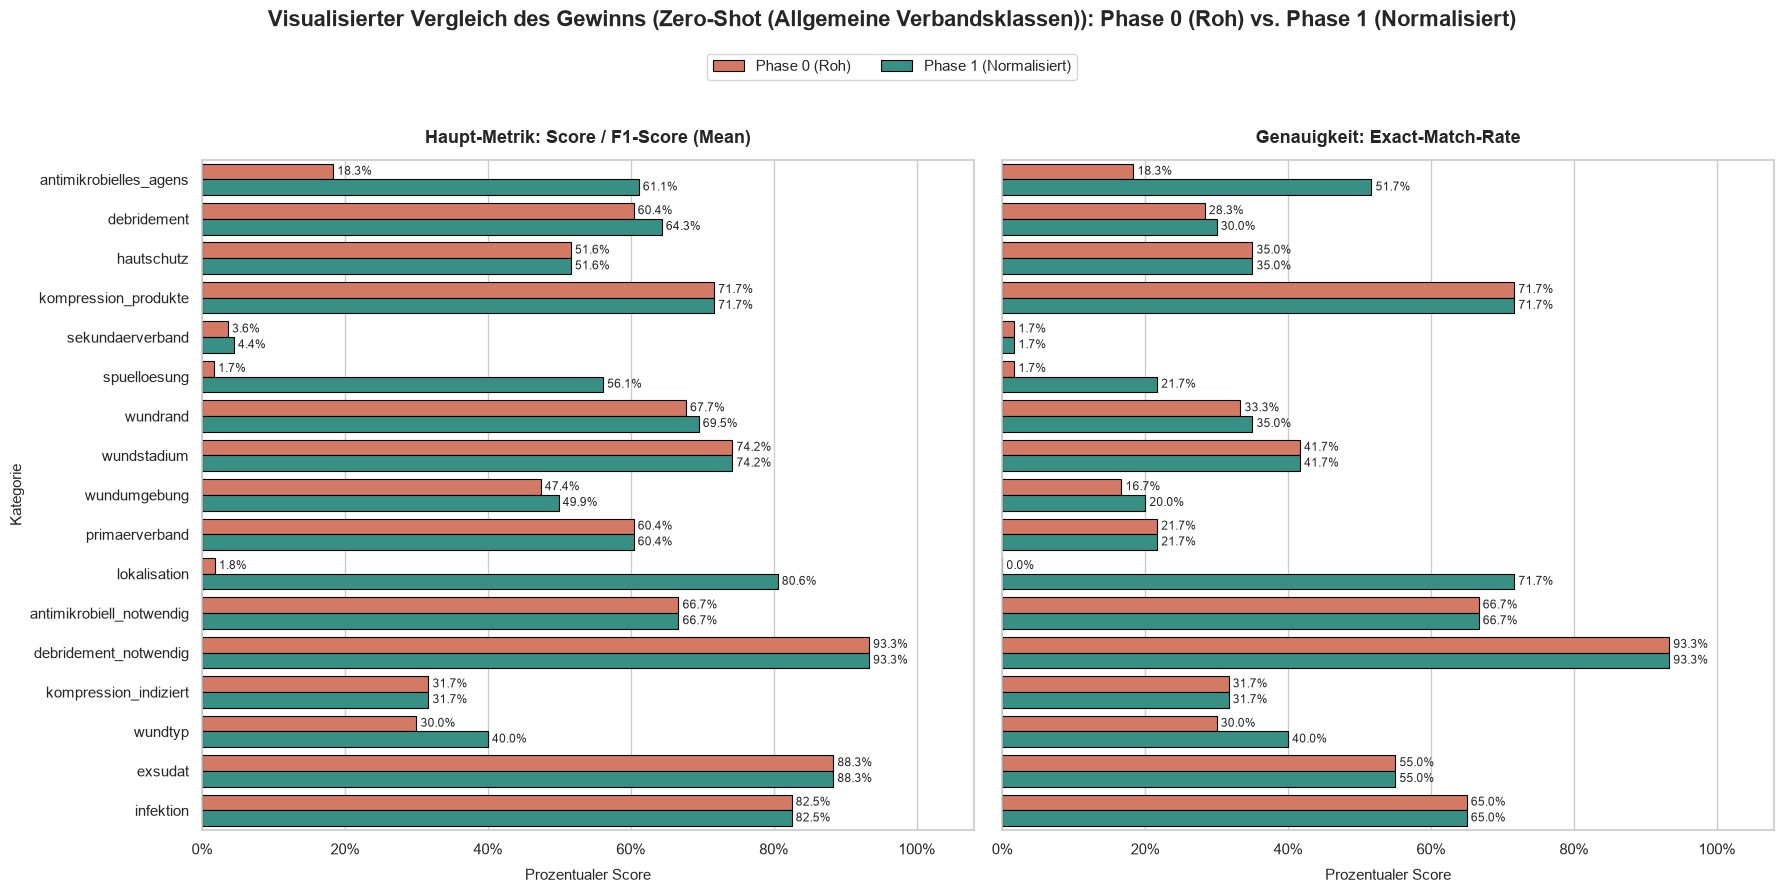

In [2]:
JSON_DIR_ZERO_SHOT = "../runs/gpt-5/zero_shot"

# Berechne Roh- und Normalisierte Scores
df_scores_zs_raw = calculate_scores(CSV_PATH, JSON_DIR_ZERO_SHOT, raw=True)
sum_zs_raw = calculate_summary(df_scores_zs_raw)

df_scores_zs_norm = calculate_scores(CSV_PATH, JSON_DIR_ZERO_SHOT, raw=False)
sum_zs_norm = calculate_summary(df_scores_zs_norm)

# Plot: Roh (Phase 0) vs Normalisiert (Phase 1)
plot_gt_comparison(sum_zs_raw, sum_zs_norm, expert_label="Zero-Shot (Allgemeine Verbandsklassen)")

## 2. Few-Shot Ansatz

Analyse des Few-Shot-Ansatzes mit 2 vordefinierten Beispielwunden (`wunde_18` & `wunde_28`).

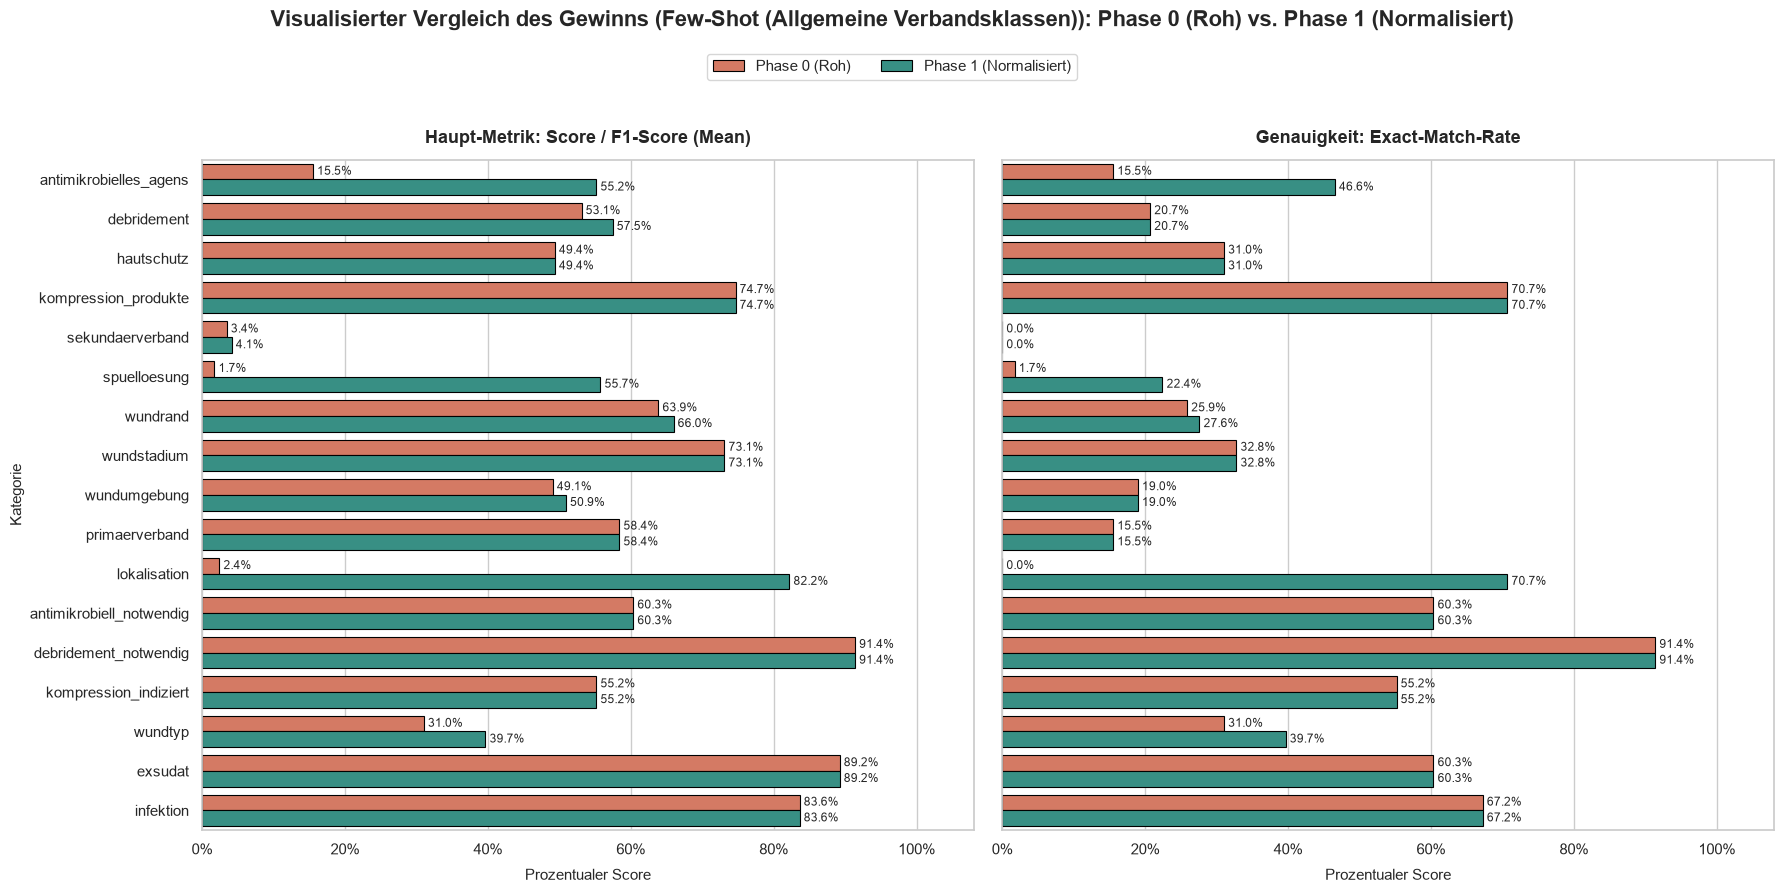

In [3]:
JSON_DIR_FEW_SHOT = "../runs/gpt-5/few_shot"

# Berechne Roh- und Normalisierte Scores
df_scores_fs_raw = calculate_scores(CSV_PATH, JSON_DIR_FEW_SHOT, raw=True)
sum_fs_raw = calculate_summary(df_scores_fs_raw)

df_scores_fs_norm = calculate_scores(CSV_PATH, JSON_DIR_FEW_SHOT, raw=False)
sum_fs_norm = calculate_summary(df_scores_fs_norm)

# Plot: Roh (Phase 0) vs Normalisiert (Phase 1)
plot_gt_comparison(sum_fs_raw, sum_fs_norm, expert_label="Few-Shot (Allgemeine Verbandsklassen)")

## 3. 2-Stage Chain-of-Thought (CoT) Ansatz

Analyse des 2-Stage CoT-Ansatzes (Stufe 1: Befundung -> Stufe 2: Produktempfehlung).

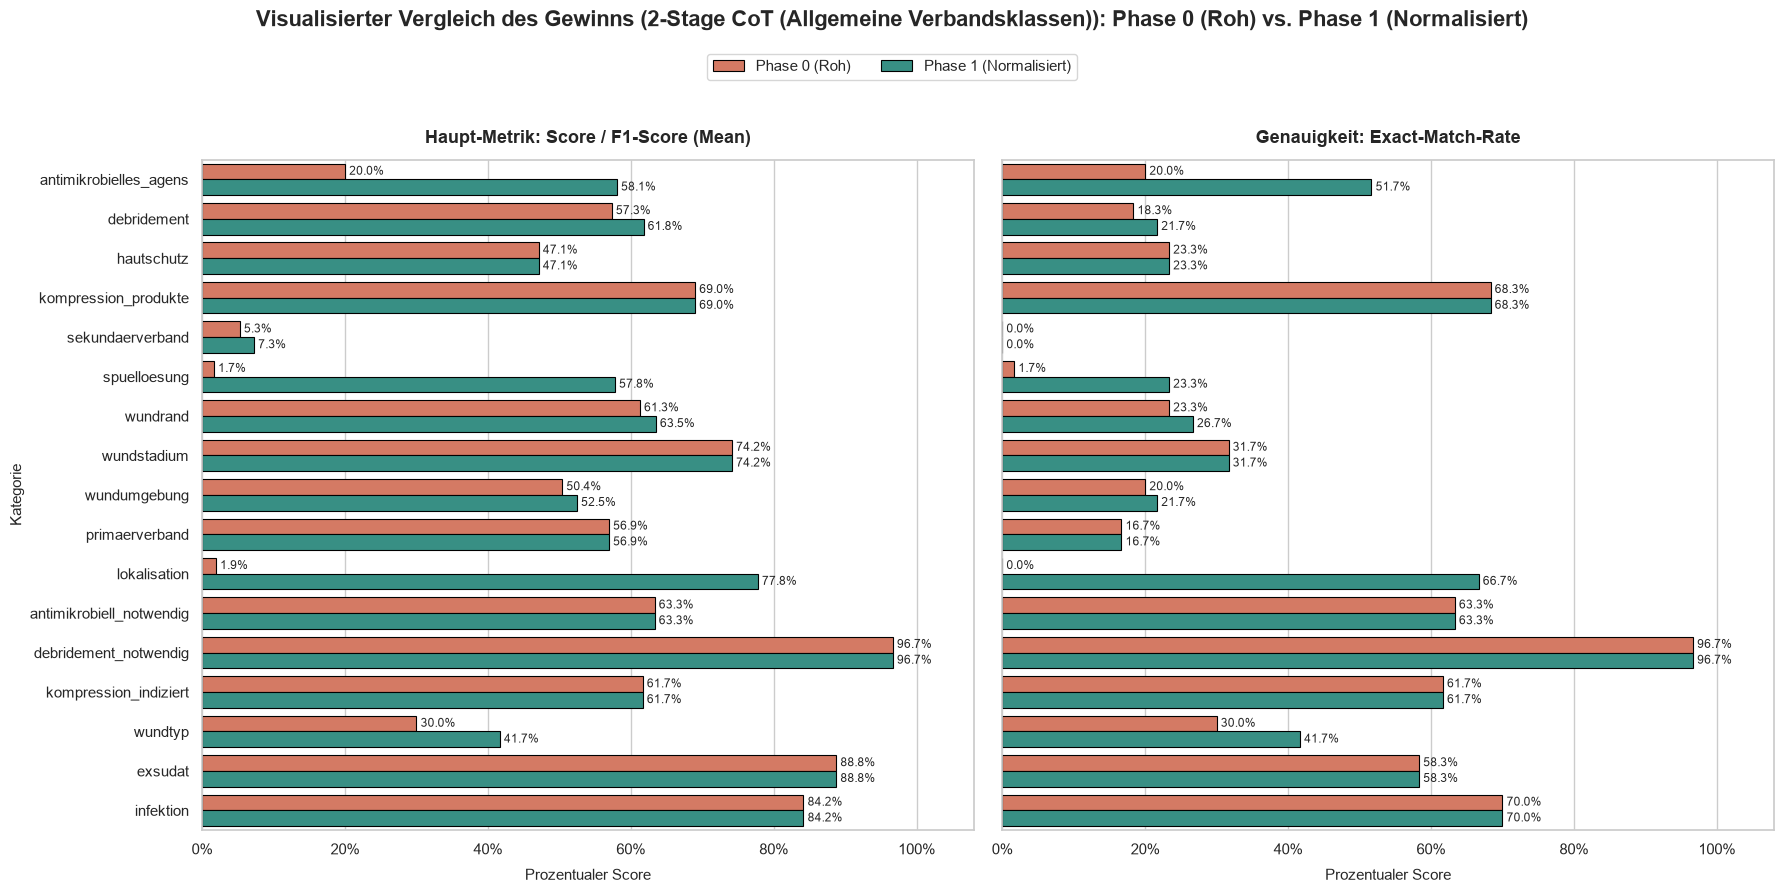

In [4]:
JSON_DIR_TWO_STAGE = "../runs/gpt-5/two_stage"

# Berechne Roh- und Normalisierte Scores
df_scores_2s_raw = calculate_scores(CSV_PATH, JSON_DIR_TWO_STAGE, raw=True)
sum_2s_raw = calculate_summary(df_scores_2s_raw)

df_scores_2s_norm = calculate_scores(CSV_PATH, JSON_DIR_TWO_STAGE, raw=False)
sum_2s_norm = calculate_summary(df_scores_2s_norm)

# Plot: Roh (Phase 0) vs Normalisiert (Phase 1)
plot_gt_comparison(sum_2s_raw, sum_2s_norm, expert_label="2-Stage CoT (Allgemeine Verbandsklassen)")

## 4. Direktvergleich aller 3 Ansätze über alle Kategorien

Gruppiertes Balkendiagramm, das die normalisierten F1-Scores / Mean Scores aller 17 Kategorien für Zero-Shot, Few-Shot und 2-Stage CoT nebeneinander vergleicht.

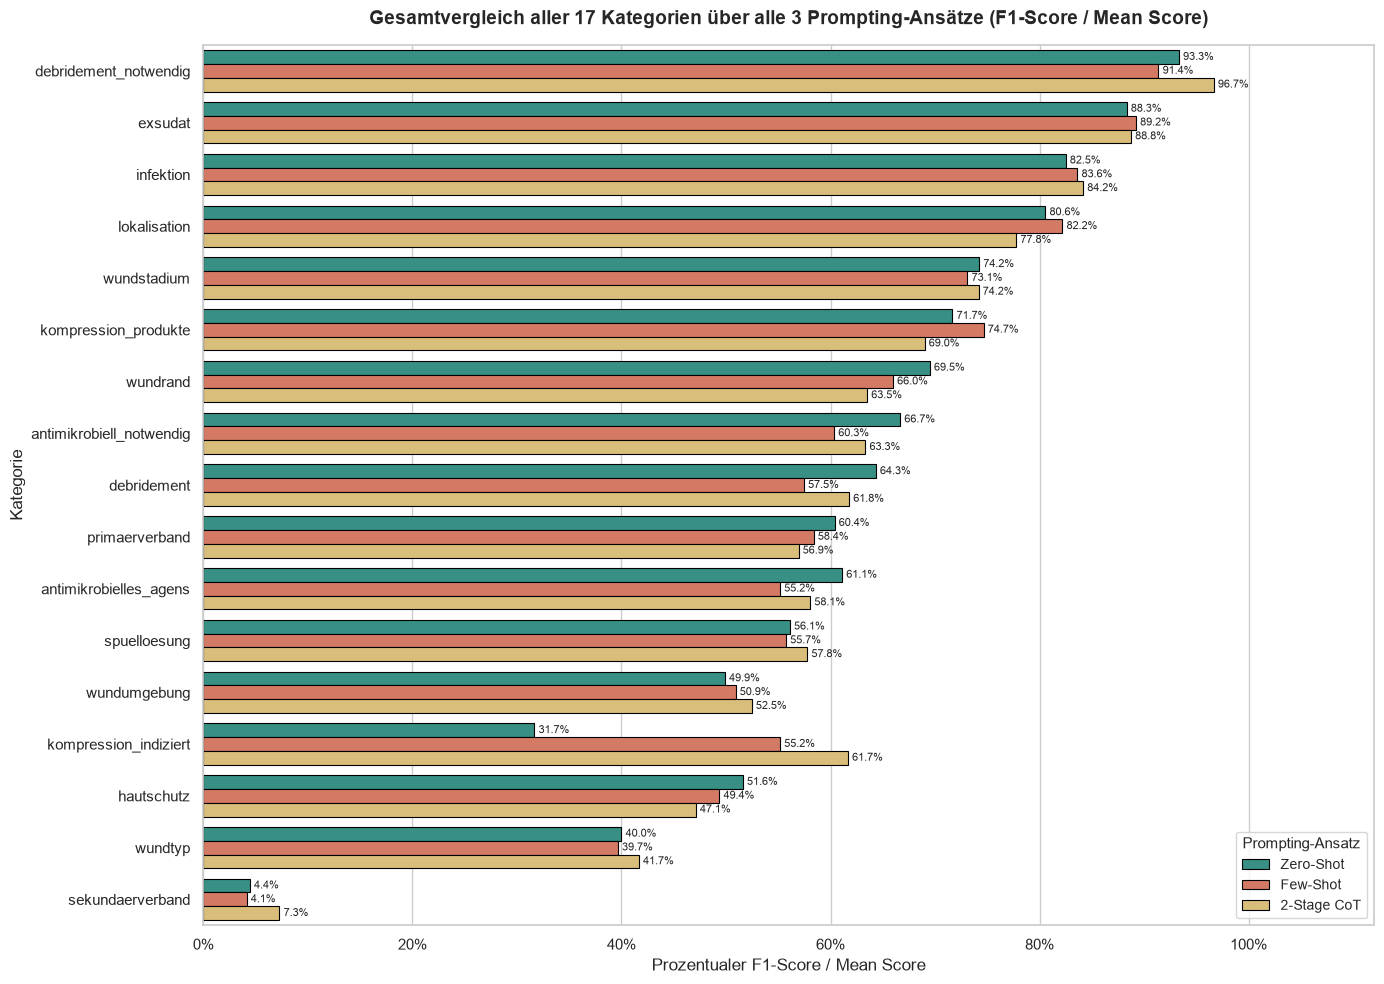

In [5]:
# Direktvergleich aller 3 Ansätze für alle 17 Kategorien
plot_all_prompts_comparison(sum_zs_norm, sum_fs_norm, sum_2s_norm)

## 5. Fokus-Vergleich: Produktempfehlungen (Primär- & Sekundärverband)

Gezielter Direktvergleich der 3 Ansätze ausschließlich für die Kernkategorien der Produktempfehlung (`primaerverband` und `sekundaerverband`).

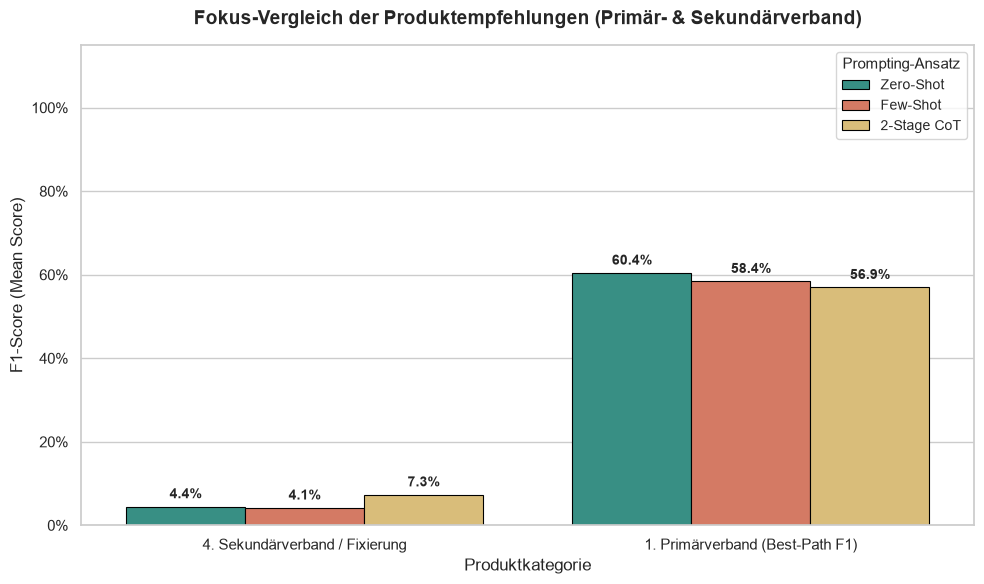

In [6]:
# Fokus-Vergleich der Produktempfehlungen (Primär- & Sekundärverband)
plot_product_prompts_comparison(sum_zs_norm, sum_fs_norm, sum_2s_norm)

## 6. Analyse des Gesamt-Produktsets pro Wundbild (Primär + Sekundär + Hautschutz)

Hier werden alle empfohlenen Produkte aus **Primärverband (Präferenz & Alternative)**, **Sekundärverband** und **Wundrand/Hautschutz** pro Wundbild in ein einziges Gesamt-Set zusammengefügt und bewertet.

## 7. Wortanzahl & Token-Effizienz der Roh-Antworten

Analyse der Textlänge (Wortanzahl) der Roh-Antworten pro Wundbild und Vergleich der Token-Effizienz (Gesamt-Set F1-Score % / Ø Wortanzahl).

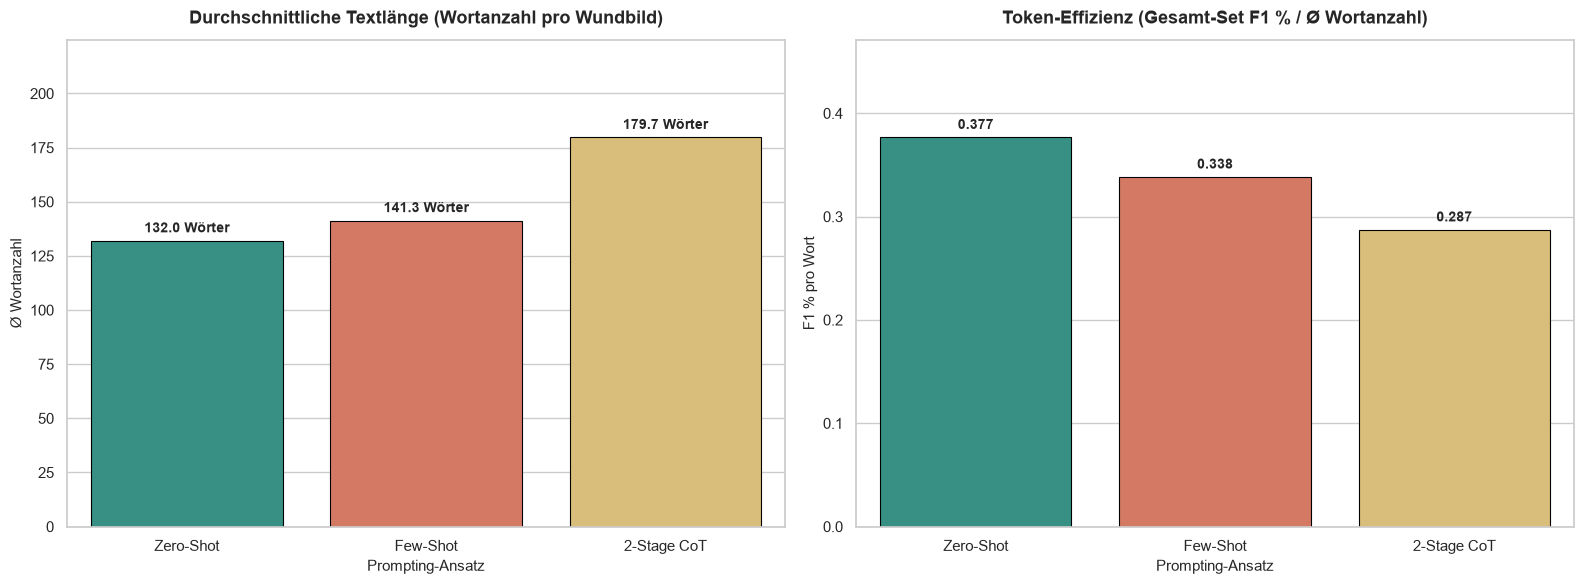

In [9]:
# Plot: Ø Wortanzahl pro Wundbild und Token-Effizienz Index
plot_word_count_analysis(
    json_dir_zs=JSON_DIR_ZERO_SHOT,
    json_dir_fs=JSON_DIR_FEW_SHOT,
    json_dir_2s=JSON_DIR_TWO_STAGE
)

## 8. Aggregatebene & Baselines (Score / F1-Score & Exact Match)

Aggregierte Auswertung über alle 17 Kategorien der allgemeinen Verbandsklassen für **Score / F1-Score (Mean)** und **Exact-Match-Rate** im Vergleich mit den beiden Baselines (Majority Baseline LOO & Random Baseline).

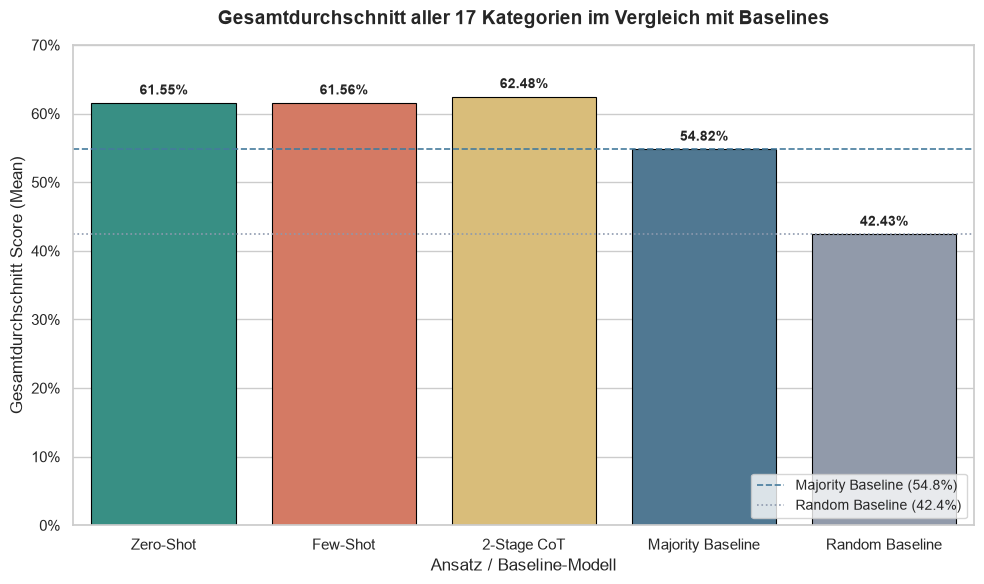

In [11]:
# Plot 1: Aggregierter Gesamtdurchschnitt Score (Mean) vs. Baselines
plot_overall_scores_with_baselines(
    csv_path=CSV_PATH,
    json_dir_zs=JSON_DIR_ZERO_SHOT,
    json_dir_fs=JSON_DIR_FEW_SHOT,
    json_dir_2s=JSON_DIR_TWO_STAGE
)

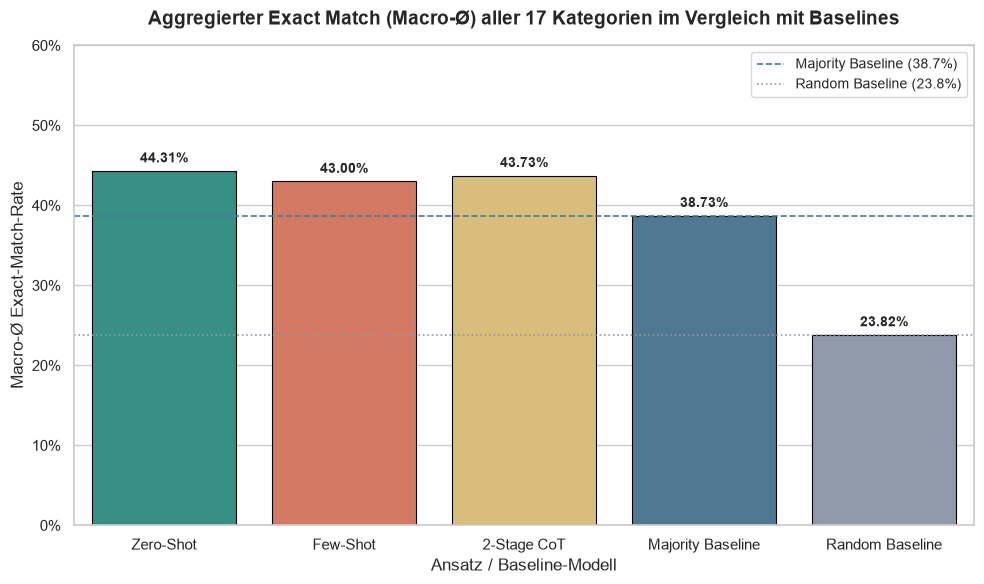

In [12]:
# Plot 2: Aggregierte Macro-Ø Exact-Match-Rate vs. Baselines
plot_exact_match_overall_comparison(
    csv_path=CSV_PATH,
    json_dir_zs=JSON_DIR_ZERO_SHOT,
    json_dir_fs=JSON_DIR_FEW_SHOT,
    json_dir_2s=JSON_DIR_TWO_STAGE
)

## 9. Kategorieebene: Wissenschaftliche Ergebnis-Heatmap

Zweigeteilte wissenschaftliche Ergebnis-Heatmap (Baselines vs. LLM-Ansätze) analog zu `heatmap_lr.py`, geordnet nach klinischen Clustern (Wundcharakterisierung, Infektion/Debridement, Verband/Hautschutz, Kompression) inklusive Macro-Ø Fußzeile.

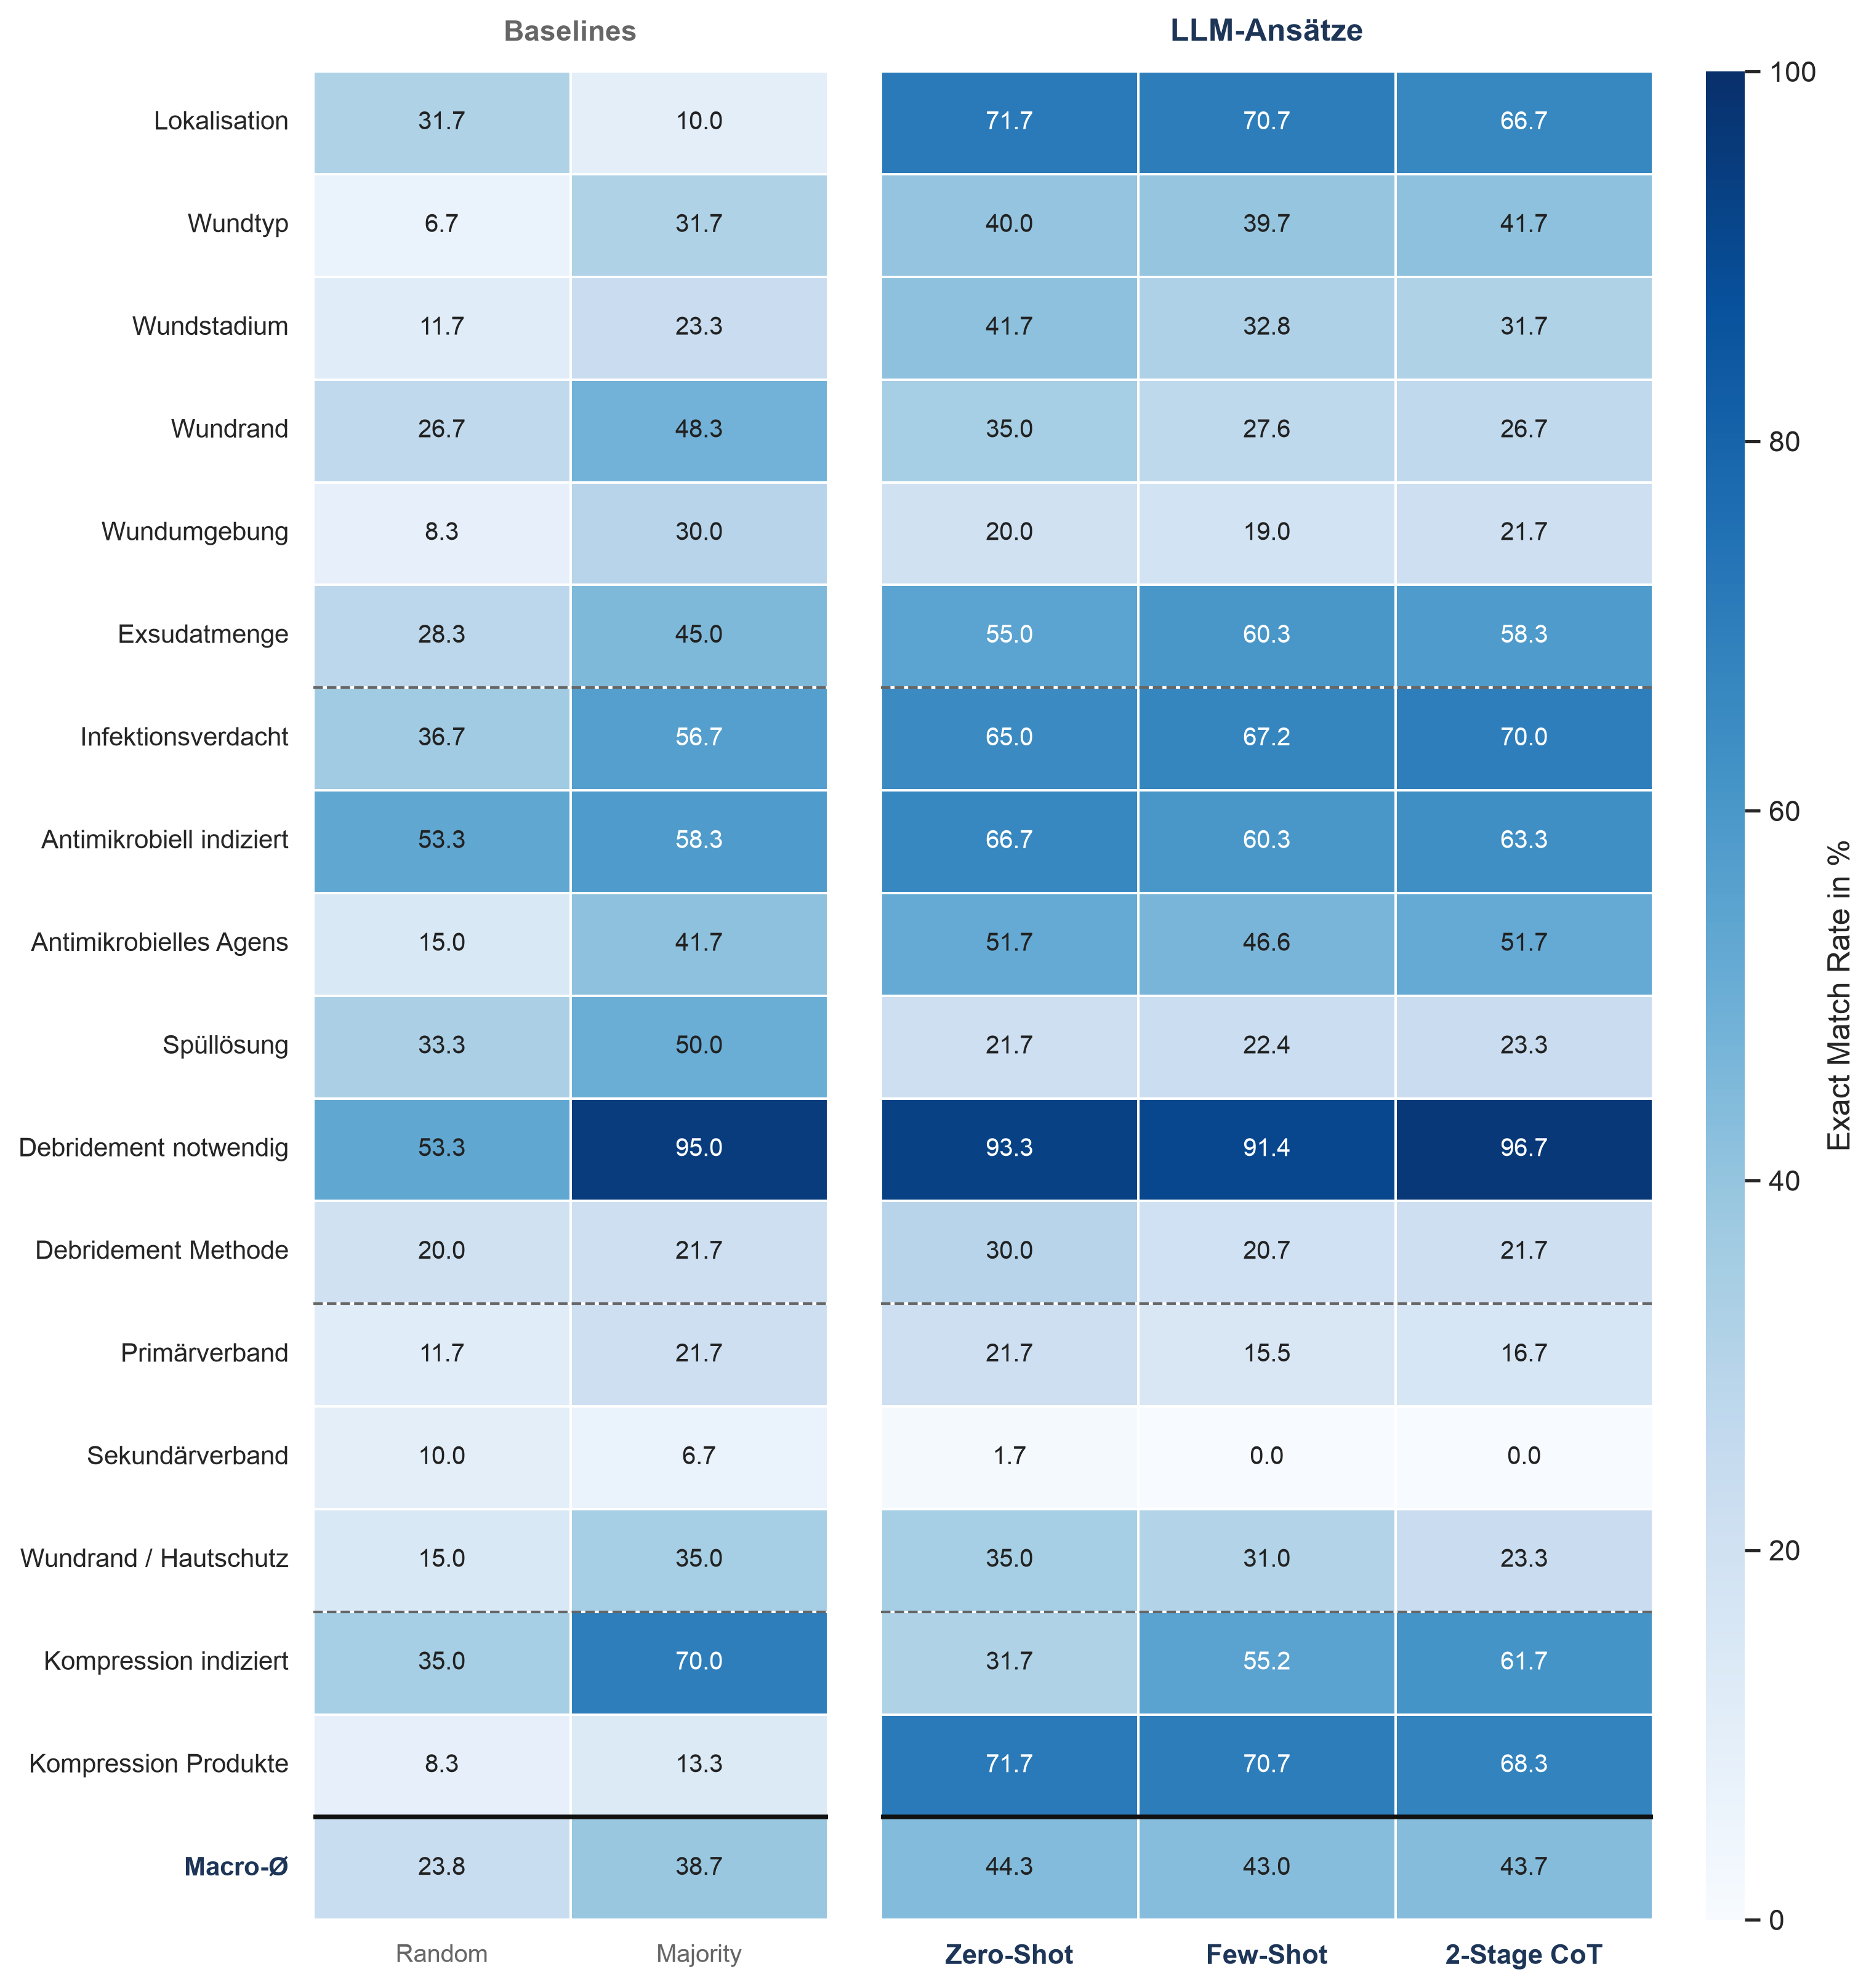

In [13]:
# Scientific Heatmap: Exact Match Rate in % (Baselines | LLM-Ansätze)
plot_results_heatmap_general(
    csv_path=CSV_PATH,
    json_dir_zs=JSON_DIR_ZERO_SHOT,
    json_dir_fs=JSON_DIR_FEW_SHOT,
    json_dir_2s=JSON_DIR_TWO_STAGE,
    metric_type="exact",
    cmap="Blues"
)

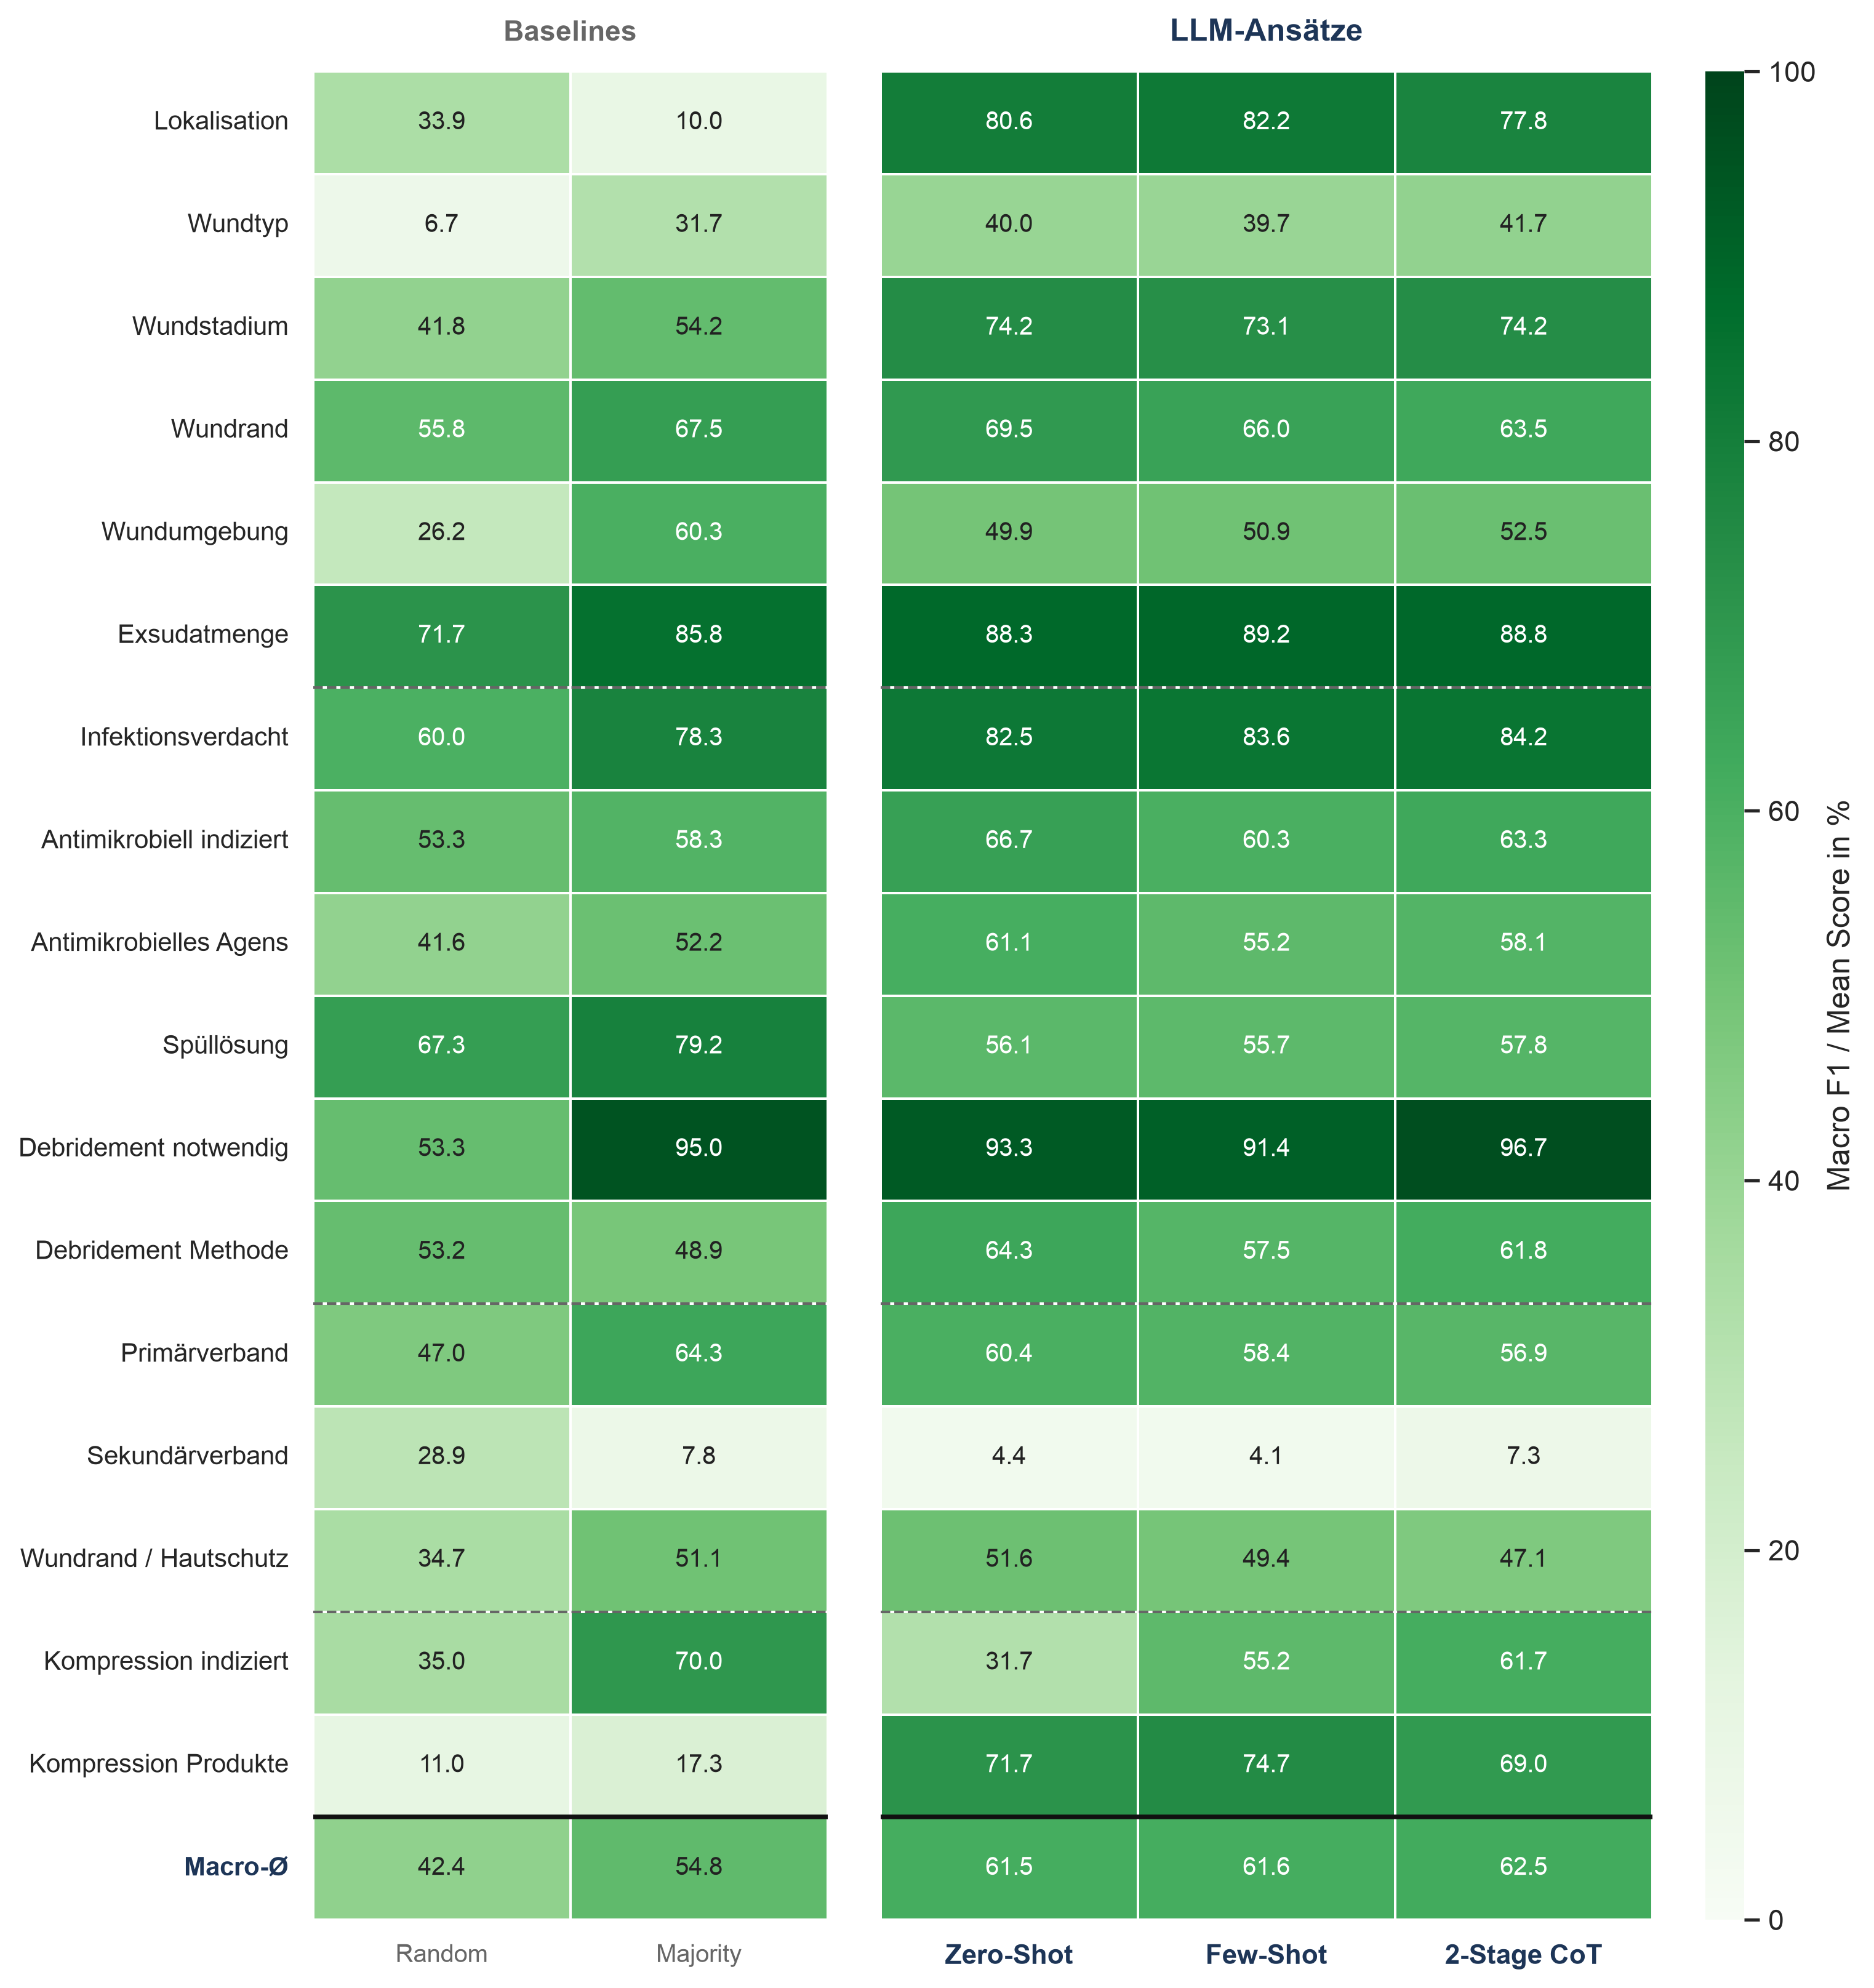

In [14]:
# Scientific Heatmap: Score / Macro F1 in % (Baselines | LLM-Ansätze)
plot_results_heatmap_general(
    csv_path=CSV_PATH,
    json_dir_zs=JSON_DIR_ZERO_SHOT,
    json_dir_fs=JSON_DIR_FEW_SHOT,
    json_dir_2s=JSON_DIR_TWO_STAGE,
    metric_type="f1",
    cmap="Greens"
)

## 10. Zusammenfassung der Ergebnisse für die Masterarbeit

### 📌 1. Gesamt-Performance auf Aggregatebene (17 Kategorien)
* **Evaluierte Kategorien:** 17 klinische Parameter und Produktklassen (L&R-Spezialfelder wie `wundgrund` wurden herausgefiltert).
* **Score / F1-Score (Mean):**
  * 🥇 **2-Stage CoT:** **62,48 %**
  * 🥈 **Few-Shot:** **61,56 %**
  * 🥉 **Zero-Shot:** **61,55 %**
  * 📊 **Majority Baseline (LOO):** **54,82 %**
  * 🎲 **Random Baseline:** **42,43 %**
* **Exact-Match-Rate (Exakte Übereinstimmung):**
  * 🥇 **Zero-Shot:** **44,31 %**
  * 🥈 **2-Stage CoT:** **43,73 %**
  * 🥉 **Few-Shot:** **43,00 %**
  * 📊 **Majority Baseline (LOO):** **38,73 %**
  * 🎲 **Random Baseline:** **23,82 %**
* **Erkenntnis:** Alle 3 LLM-Ansätze übertreffen die **Majority Baseline auf Aggregatebene deutlich um +7,7 Prozentpunkte (F1)** und schlagen die **Random Baseline um über +20 Prozentpunkte**.

---

### 📌 2. Auswertung der Produktempfehlungen (Primärverband)
* **Primärverband (Best-Path F1):**
  * **Zero-Shot:** **60,4 %** (Exact Match: 21,7 %)
  * **Few-Shot:** **58,4 %** (Exact Match: 15,5 %)
  * **2-Stage CoT:** **56,9 %** (Exact Match: 16,7 %)
* **Ursache für die ~60 % Grenze:** In der Wundversorgung existieren bei fast jeder Wunde mehrere medizinisch gleichwertige Behandlungsoptionen (z. B. Hydrofaser vs. Alginat). Die starre Fixierung der Evaluation auf die Präferenz des einen Experten im Ground Truth bildet eine natürliche Obergrenze.

---

### 📌 3. Gesamt-Produktset Evaluation (Primär + Sekundär + Hautschutz kombiniert)
* **Hintergrund:** Experten nutzen Produkte wie Schaumstoffverbände klinisch flexibel – sowohl als Primärverband als auch als sekundäre Schutzabdeckung. Das Gesamt-Set hebt starre Kategoriegrenzen auf.
* **Ergebnisse (Phase 1 Normalisiert):**
  * 🥇 **2-Stage CoT:** **51,6 %** *(Phase 0 Roh: 40,6 % -> **+11,0 %** durch Mapping)*
  * 🥈 **Zero-Shot:** **49,7 %** *(Phase 0 Roh: 40,6 % -> **+9,1 %** durch Mapping)*
  * 🥉 **Few-Shot:** **47,8 %** *(Phase 0 Roh: 39,7 % -> **+8,1 %** durch Mapping)*
* **Kernerkenntnis:** 
  1. **2-Stage CoT wird beim Gesamt-Set zum Testsieger (51,6 %)**, da die zweistufige Befundung in Stufe 1 zu einer umfassenderen Erfassung aller benötigten Produktkomponenten in Stufe 2 führt.
  2. Das Gesamt-Set übertrifft den Durchschnitt der 3 isolierten Kategorien (**38,5 %**) um **+13,1 Prozentpunkte**, da Zuordnungs-Verwechslungen zwischen Primär- und Sekundärverband aufgefangen werden.

---

### 📌 4. Fallstudie: Kompressionstherapie (`kompression_indiziert` – CoT-Mehrwert)
* **Klassenergebnisse:**
  * 🥇 **2-Stage CoT:** **61,67 %** Exact Match *(Verdopplung der Genauigkeit!)*
  * 🥈 **Few-Shot:** **55,17 %** Exact Match
  * 🥉 **Zero-Shot:** **31,67 %** Exact Match
* **Ursache des riesigen Unterschieds (+30,0 % für 2-Stage CoT):**
  1. **Zero-Shot Enthaltsamkeit:** Ohne Zwischenanalyse wählt Zero-Shot bei der kritischen Kontraindikations-Frage in 65 % der Fälle defensiv die Ausweichantwort `nicht beurteilbar` (GT verlangt in 70 % der Wunden klipp und klar `Nein`).
  2. **CoT Befundungs-Kette:** 2-Stage CoT wird in Stufe 1 gezwungen, die Wundumgebung (Ödem, CVI-Symptome, Durchblutung) explizit zu analysieren. Diese visuelle Voranalyse baut die Enthaltungs-Blockade ab und führt in Stufe 2 zu korrekten `Ja`/`Nein`-Entscheidungen.

---

### 📌 5. Textlänge (Wortanzahl) & Token-Effizienz
* **Durchschnittliche Wortanzahl der Roh-Antworten pro Wundbild:**
  * **Zero-Shot:** Ø **132,0 Wörter** *(Kompaktestes JSON)*
  * **Few-Shot:** Ø **141,3 Wörter** *(Mittelfeld durch Nachahmung der Prompt-Beispiele)*
  * **2-Stage CoT:** Ø **179,7 Wörter** *(Längster Text durch 2 aufeinanderfolgende Stufen)*
* **Token-Effizienz-Index (Gesamt-Set F1-Score % / Ø Wortanzahl):**
  * 🥇 **Zero-Shot:** **0,377** *(Höchste Effizienz: Sehr hoher F1-Score bei minimalem Token-Verbrauch)*
  * 🥈 **Few-Shot:** **0,338**
  * 🥉 **2-Stage CoT:** **0,287** *(Erreicht zwar die höchste Genauigkeit, benötigt dafür aber 36 % mehr Text)*

---

### 📌 6. Fazit & Empfehlungen

| Anwendungsfall | Empfohlener Prompting-Ansatz | Begründung |
| :--- | :--- | :--- |
| **Beste Gesamt-Abdeckung & Indikationsentscheide** | **2-Stage CoT** | Erreicht beim Gesamt-Produktset (**51,6 %**), der Gesamt-Macro-F1 (**62,48 %**) und bei Indikationen wie Kompression (**61,67 %**) die besten Ergebnisse. |
| **Höchste Effizienz & Praxistauglichkeit** | **Zero-Shot** | Liefert bei minimaler Wortanzahl (132 Wörter) die höchste Token-Effizienz (**0,377**), die beste Primärverbands-Quote (**60,4 %**) und den höchsten Exact Match (**44,31 %**). |